In [1]:
import torch
from data import get_loader
from model import *
from metrics import metric_psnr, metric_ssim
from tqdm import tqdm
from data import *
import matplotlib.pyplot as plt

/mnt/nvme0/home/utbt/miniconda3/envs/venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import torch
# import matplotlib.pyplot as plt
# import cv2
# import numpy as np
# import os

# from model import *


# def load_sequence(folder):
#     frames = []
#     files = sorted(os.listdir(folder))

#     for f in files:
#         img = cv2.imread(os.path.join(folder, f))

#         # IMPORTANT:
#         # KHONG convert BGR -> RGB
#         # vi pretrained OpenMMLab model dung BGR convention
#         img = img.astype(np.float32) / 255.0

#         frames.append(img)

#     frames = np.stack(frames, axis=0)          # (T, H, W, C)
#     frames = np.transpose(frames, (0, 3, 1, 2))  # (T, C, H, W)

#     return torch.from_numpy(frames)


# def tensor_to_rgb(img_tensor):

#     img = (
#         img_tensor
#         .detach()
#         .cpu()
#         .clamp(0, 1)
#         .permute(1, 2, 0)
#         .numpy()
#     )

#     img = img[..., ::-1]

#     return img


# device = 'cuda:1' if torch.cuda.is_available() else 'cpu'

# model = BasicVSRWrapper(checkpoint_path='./checkpoints/basicvsr_checkpoints/basicvsr_reds4_20120409-0e599677.pth', device=device)
# model = EDVRWrapper(checkpoint_path='./checkpoints/edvr_checkpoints/edvrl_c128b40_8x8_lr2e-4_600k_reds4_20220104-4509865f.pth', device=device)
# model = RSDNWrapper(checkpoint_path='./checkpoints/rsdn_checkpoints/RSDN.pth', device=device)
# model = OVSRWrapper(checkpoint_path='./checkpoints/ovsr_checkpoints/0721.pth', device=device)

# bi_path = './data/Vid4/BIx4/walk'
# gt_path = './data/Vid4/GT/walk'

# bi = load_sequence(bi_path)
# gt = load_sequence(gt_path)

# bi = bi.unsqueeze(0)
# gt = gt.unsqueeze(0)

# bi_input = bi.to(device)
# gt = gt.to(device)

# with torch.no_grad():
#     pred = model(bi_input)


# num_imgs = bi_input.shape[1]

# plt.figure(figsize=(18, 6 * num_imgs))
# plt.rcParams.update({'font.size': 30})

# i = 1

# for j in range(num_imgs):

#     # Ground truth
#     plt.subplot(num_imgs, 3, i)
#     plt.imshow(tensor_to_rgb(gt[0][j]))
#     plt.axis('off')

#     if i == 1:
#         plt.title('Ground truth')

#     i += 1

#     # Input
#     plt.subplot(num_imgs, 3, i)
#     plt.imshow(tensor_to_rgb(bi_input[0][j]))
#     plt.axis('off')

#     if i == 2:
#         plt.title('Input')

#     i += 1

#     # Prediction
#     plt.subplot(num_imgs, 3, i)
#     plt.imshow(tensor_to_rgb(pred[0][j]))
#     plt.axis('off')

#     if i == 3:
#         plt.title('Prediction')

#     i += 1

# plt.tight_layout(pad=2.0)
# plt.show()

Running BasicVSR...
Running EDVR...
Running RSDN...


/mnt/nvme0/home/utbt/miniconda3/envs/venv/lib/python3.8/site-packages/torch/nn/functional.py:3679: UserWarning: The default behavior for interpolate/upsample with float scale_factor changed in 1.6.0 to align with other frameworks/libraries, and now uses scale_factor directly, instead of relying on the computed output size. If you wish to restore the old behavior, please set recompute_scale_factor=True. See the documentation of nn.Upsample for details. 
  warnings.warn(
/mnt/nvme0/home/utbt/miniconda3/envs/venv/lib/python3.8/site-packages/torch/nn/functional.py:1806: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


Running OVSR...


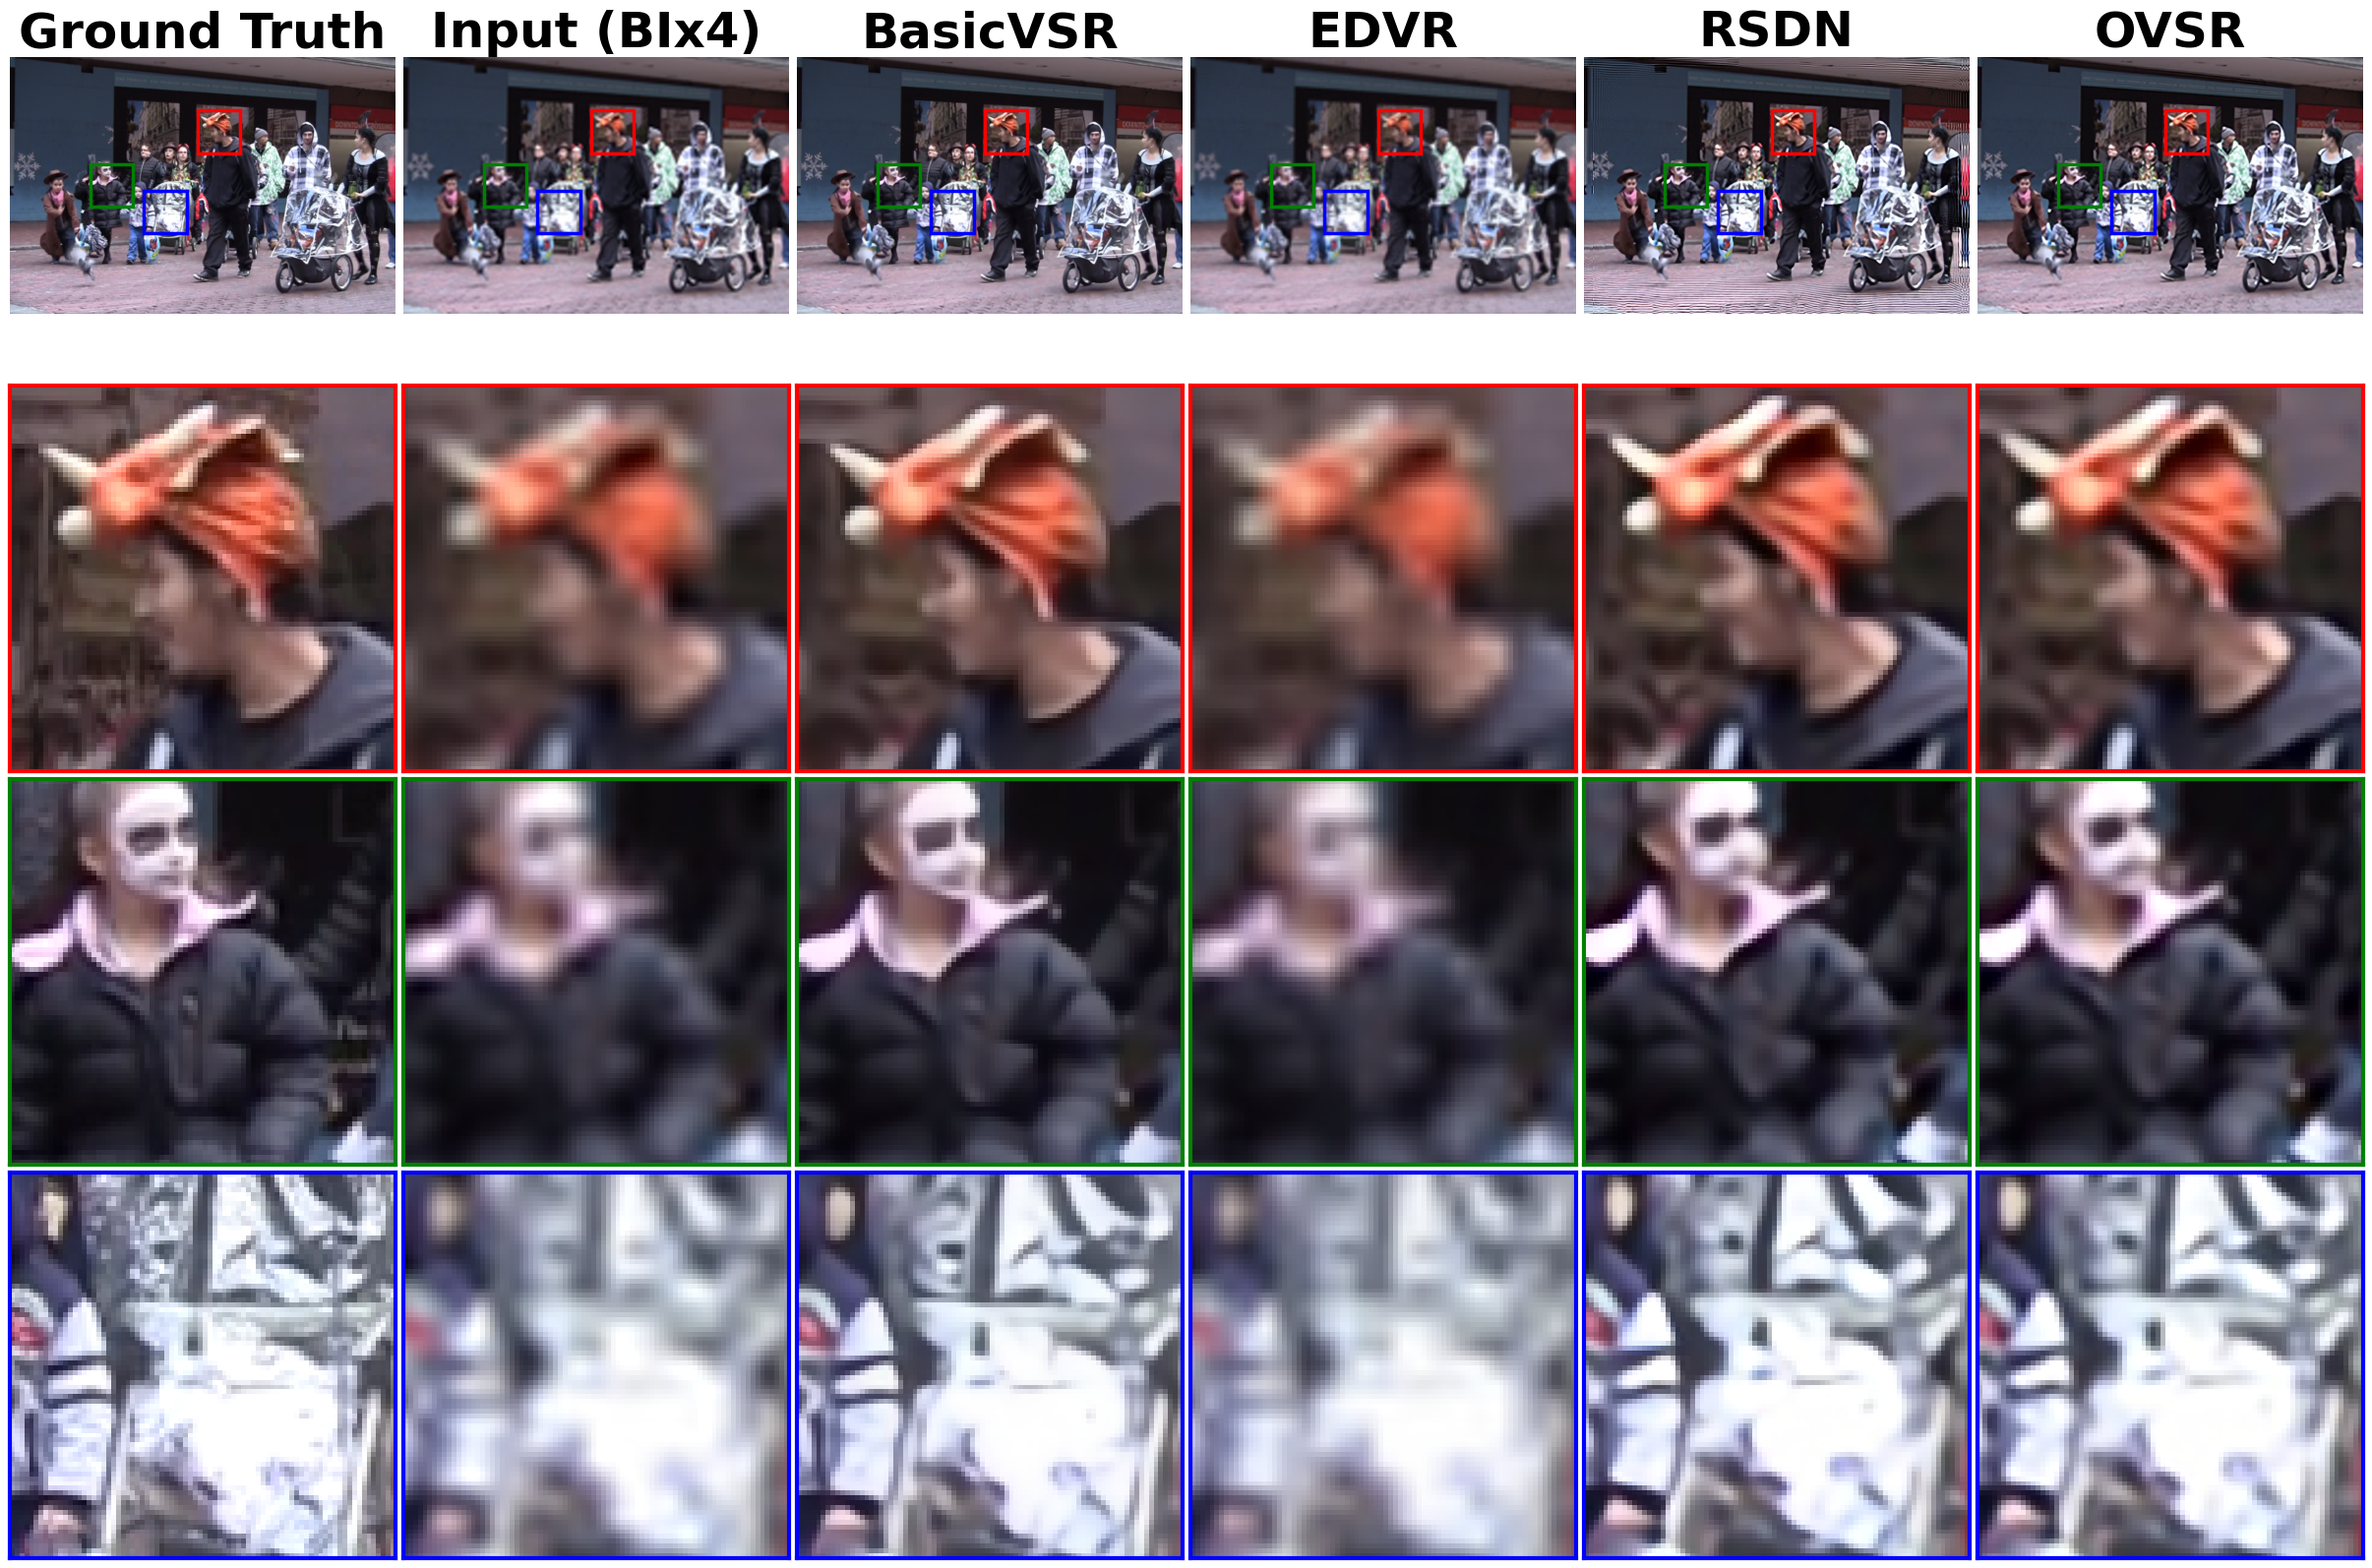

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np
import os

from model import *

def load_sequence(folder):
    frames = []
    files = sorted(os.listdir(folder))

    for f in files:
        img = cv2.imread(os.path.join(folder, f))

        # IMPORTANT:
        # KHONG convert BGR -> RGB
        # vi pretrained OpenMMLab model dung BGR convention
        img = img.astype(np.float32) / 255.0

        frames.append(img)

    frames = np.stack(frames, axis=0)             # (T, H, W, C)
    frames = np.transpose(frames, (0, 3, 1, 2))  # (T, C, H, W)

    return torch.from_numpy(frames)


def tensor_to_rgb(img_tensor):
    img = (
        img_tensor
        .detach()
        .cpu()
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )

    # BGR -> RGB for matplotlib
    img = img[..., ::-1]

    return img


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# =========================
# Load all models
# =========================
models = {
    'BasicVSR': BasicVSRWrapper(
        checkpoint_path='./checkpoints/basicvsr_checkpoints/basicvsr_reds4_20120409-0e599677.pth',
        device=device
    ),
    'EDVR': EDVRWrapper(
        checkpoint_path='./checkpoints/edvr_checkpoints/edvrl_c128b40_8x8_lr2e-4_600k_reds4_20220104-4509865f.pth',
        device=device
    ),
    'RSDN': RSDNWrapper(
        checkpoint_path='./checkpoints/rsdn_checkpoints/RSDN.pth',
        device=device
    ),
    'OVSR': OVSRWrapper(
        checkpoint_path='./checkpoints/ovsr_checkpoints/0721.pth',
        device=device
    )
}

# =========================
# Load data
# =========================
bi_path = './data/Vid4/BIx4/walk'
gt_path = './data/Vid4/GT/walk'

bi = load_sequence(bi_path)
gt = load_sequence(gt_path)

bi = bi.unsqueeze(0).to(device)
gt = gt.unsqueeze(0).to(device)

# =========================
# Run inference
# =========================
predictions = {}
with torch.no_grad():
    for model_name, model in models.items():
        print(f'Running {model_name}...')
        pred = model(bi)
        predictions[model_name] = pred

# =========================
# Select frame index
# =========================
frame_idx = 10

# =========================
# Plot (Updated Layout with 3 crops)
# =========================

# Upsample input BI lên HR bằng bicubic để crop và hiển thị đồng nhất với các output khác
bi_upsampled = F.interpolate(bi[0:1, frame_idx], size=(gt.shape[-2], gt.shape[-1]), mode='bicubic', align_corners=False)

titles = [
    'Ground Truth',
    'Input (BIx4)',
    'BasicVSR',
    'EDVR',
    'RSDN',
    'OVSR'
]

images = [
    gt[0][frame_idx],
    bi_upsampled[0], 
    predictions['BasicVSR'][0][frame_idx],
    predictions['EDVR'][0][frame_idx],
    predictions['RSDN'][0][frame_idx],
    predictions['OVSR'][0][frame_idx],
]

# Danh sách các vùng muốn zoom. 
# Vùng 1 giữ nguyên, Vùng 2 và 3 bạn điều chỉnh toạ độ x, y cho phù hợp ảnh của bạn nhé.
crops = [
    {'x': 350, 'y': 100, 'w': 80, 'h': 80, 'color': 'red'},     # Hàng zoom 1
    {'x': 150, 'y': 200, 'w': 80, 'h': 80, 'color': 'green'},   # Hàng zoom 2 (Tuỳ chỉnh x, y)
    {'x': 250, 'y': 250, 'w': 80, 'h': 80, 'color': 'blue'}     # Hàng zoom 3 (Tuỳ chỉnh x, y)
]

# Chuyển đổi toàn bộ tensor sang numpy RGB một lần
rgb_images = [tensor_to_rgb(img) for img in images]

# Tạo grid 4 hàng, 6 cột. Tăng chiều cao figsize để chứa đủ 4 hàng.
fig, axes = plt.subplots(4, 6, figsize=(24, 16), constrained_layout=True)
plt.rcParams.update({'font.size': 86})

for i, img in enumerate(rgb_images):
    # --- ROW 1: Ảnh gốc + 3 Bounding Boxes ---
    ax_full = axes[0, i]
    ax_full.imshow(img)
    ax_full.set_title(titles[i], fontsize=36, fontweight='bold')
    ax_full.axis('off')
    
    # Vẽ cả 3 bounding box lên ảnh gốc
    for crop in crops:
        rect = patches.Rectangle((crop['x'], crop['y']), crop['w'], crop['h'], 
                                 linewidth=2.5, edgecolor=crop['color'], facecolor='none')
        ax_full.add_patch(rect)
    
    # --- ROW 2, 3, 4: Ảnh Zoom-in tương ứng ---
    for j, crop in enumerate(crops):
        # j = 0 -> Hàng 2 (axes[1, i]), j = 1 -> Hàng 3 (axes[2, i]), j = 2 -> Hàng 4 (axes[3, i])
        ax_zoom = axes[j + 1, i]
        
        # Cắt ảnh theo toạ độ
        img_crop = img[crop['y'] : crop['y'] + crop['h'], crop['x'] : crop['x'] + crop['w']]
        ax_zoom.imshow(img_crop)
        
        # Ẩn các mốc toạ độ (ticks) nhưng giữ lại viền (spines)
        ax_zoom.set_xticks([])
        ax_zoom.set_yticks([])
        
        # Đổi màu viền khung zoom cho trùng với màu bounding box trên ảnh gốc
        for spine in ax_zoom.spines.values():
            spine.set_edgecolor(crop['color'])
            spine.set_linewidth(3)

plt.show()

Running BasicVSR...
Running EDVR...
Running RSDN...
Running OVSR...


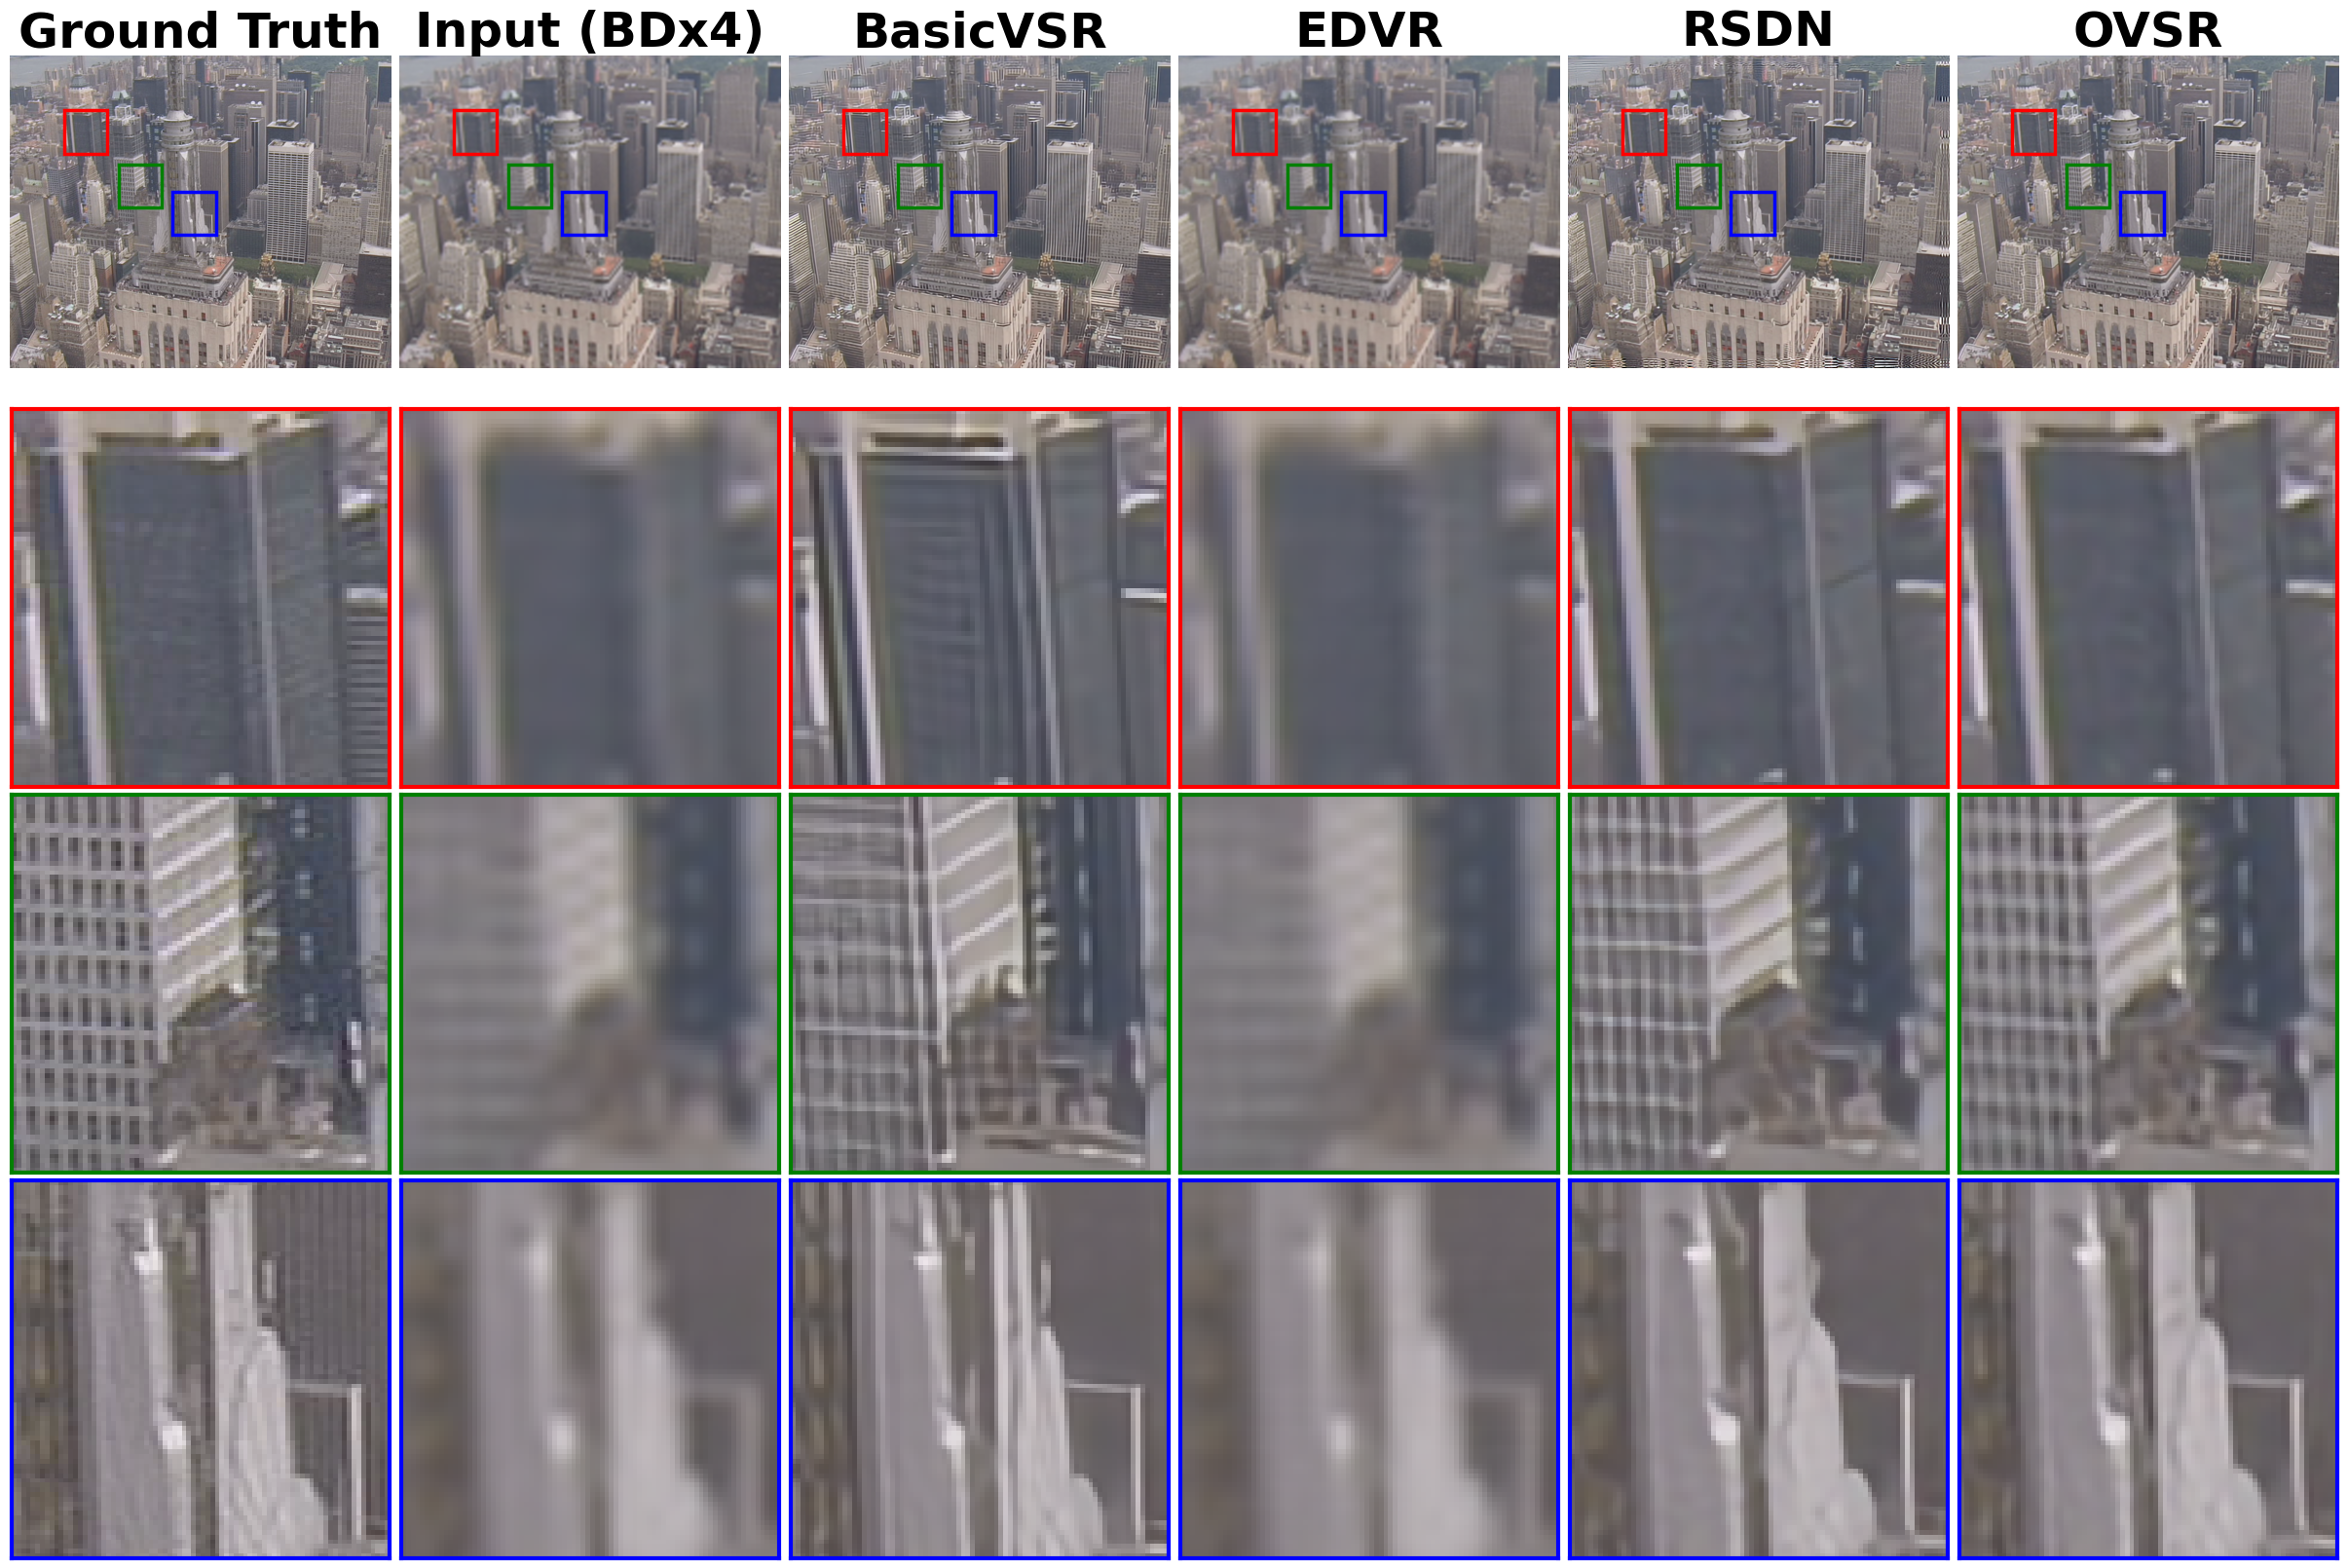

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np
import os

from model import *

def load_sequence(folder):
    frames = []
    files = sorted(os.listdir(folder))

    for f in files:
        img = cv2.imread(os.path.join(folder, f))

        # IMPORTANT:
        # KHONG convert BGR -> RGB
        # vi pretrained OpenMMLab model dung BGR convention
        img = img.astype(np.float32) / 255.0

        frames.append(img)

    frames = np.stack(frames, axis=0)             # (T, H, W, C)
    frames = np.transpose(frames, (0, 3, 1, 2))  # (T, C, H, W)

    return torch.from_numpy(frames)


def tensor_to_rgb(img_tensor):
    img = (
        img_tensor
        .detach()
        .cpu()
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )

    # BGR -> RGB for matplotlib
    img = img[..., ::-1]

    return img


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# =========================
# Load all models
# =========================
models = {
    'BasicVSR': BasicVSRWrapper(
        checkpoint_path='./checkpoints/basicvsr_checkpoints/basicvsr_reds4_20120409-0e599677.pth',
        device=device
    ),
    'EDVR': EDVRWrapper(
        checkpoint_path='./checkpoints/edvr_checkpoints/edvrl_c128b40_8x8_lr2e-4_600k_reds4_20220104-4509865f.pth',
        device=device
    ),
    'RSDN': RSDNWrapper(
        checkpoint_path='./checkpoints/rsdn_checkpoints/RSDN.pth',
        device=device
    ),
    'OVSR': OVSRWrapper(
        checkpoint_path='./checkpoints/ovsr_checkpoints/0721.pth',
        device=device
    )
}

# =========================
# Load data
# =========================
bi_path = './data/Vid4/BDx4/city'
gt_path = './data/Vid4/GT/city'

bi = load_sequence(bi_path)
gt = load_sequence(gt_path)

bi = bi.unsqueeze(0).to(device)
gt = gt.unsqueeze(0).to(device)

# =========================
# Run inference
# =========================
predictions = {}
with torch.no_grad():
    for model_name, model in models.items():
        print(f'Running {model_name}...')
        pred = model(bi)
        predictions[model_name] = pred

# =========================
# Select frame index
# =========================
frame_idx = 10

# =========================
# Plot (Updated Layout with 3 crops)
# =========================

# Upsample input BI lên HR bằng bicubic để crop và hiển thị đồng nhất với các output khác
bi_upsampled = F.interpolate(bi[0:1, frame_idx], size=(gt.shape[-2], gt.shape[-1]), mode='bicubic', align_corners=False)

titles = [
    'Ground Truth',
    'Input (BDx4)',
    'BasicVSR',
    'EDVR',
    'RSDN',
    'OVSR'
]

images = [
    gt[0][frame_idx],
    bi_upsampled[0], 
    predictions['BasicVSR'][0][frame_idx],
    predictions['EDVR'][0][frame_idx],
    predictions['RSDN'][0][frame_idx],
    predictions['OVSR'][0][frame_idx],
]

# Danh sách các vùng muốn zoom. 
# Vùng 1 giữ nguyên, Vùng 2 và 3 bạn điều chỉnh toạ độ x, y cho phù hợp ảnh của bạn nhé.
crops = [
    {'x': 100, 'y': 100, 'w': 80, 'h': 80, 'color': 'red'},     # Hàng zoom 1
    {'x': 200, 'y': 200, 'w': 80, 'h': 80, 'color': 'green'},   # Hàng zoom 2 (Tuỳ chỉnh x, y)
    {'x': 300, 'y': 250, 'w': 80, 'h': 80, 'color': 'blue'}     # Hàng zoom 3 (Tuỳ chỉnh x, y)
]

# Chuyển đổi toàn bộ tensor sang numpy RGB một lần
rgb_images = [tensor_to_rgb(img) for img in images]

# Tạo grid 4 hàng, 6 cột. Tăng chiều cao figsize để chứa đủ 4 hàng.
fig, axes = plt.subplots(4, 6, figsize=(24, 16), constrained_layout=True)
plt.rcParams.update({'font.size': 86})

for i, img in enumerate(rgb_images):
    # --- ROW 1: Ảnh gốc + 3 Bounding Boxes ---
    ax_full = axes[0, i]
    ax_full.imshow(img)
    ax_full.set_title(titles[i], fontsize=36, fontweight='bold')
    ax_full.axis('off')
    
    # Vẽ cả 3 bounding box lên ảnh gốc
    for crop in crops:
        rect = patches.Rectangle((crop['x'], crop['y']), crop['w'], crop['h'], 
                                 linewidth=2.5, edgecolor=crop['color'], facecolor='none')
        ax_full.add_patch(rect)
    
    # --- ROW 2, 3, 4: Ảnh Zoom-in tương ứng ---
    for j, crop in enumerate(crops):
        # j = 0 -> Hàng 2 (axes[1, i]), j = 1 -> Hàng 3 (axes[2, i]), j = 2 -> Hàng 4 (axes[3, i])
        ax_zoom = axes[j + 1, i]
        
        # Cắt ảnh theo toạ độ
        img_crop = img[crop['y'] : crop['y'] + crop['h'], crop['x'] : crop['x'] + crop['w']]
        ax_zoom.imshow(img_crop)
        
        # Ẩn các mốc toạ độ (ticks) nhưng giữ lại viền (spines)
        ax_zoom.set_xticks([])
        ax_zoom.set_yticks([])
        
        # Đổi màu viền khung zoom cho trùng với màu bounding box trên ảnh gốc
        for spine in ax_zoom.spines.values():
            spine.set_edgecolor(crop['color'])
            spine.set_linewidth(3)

plt.show()

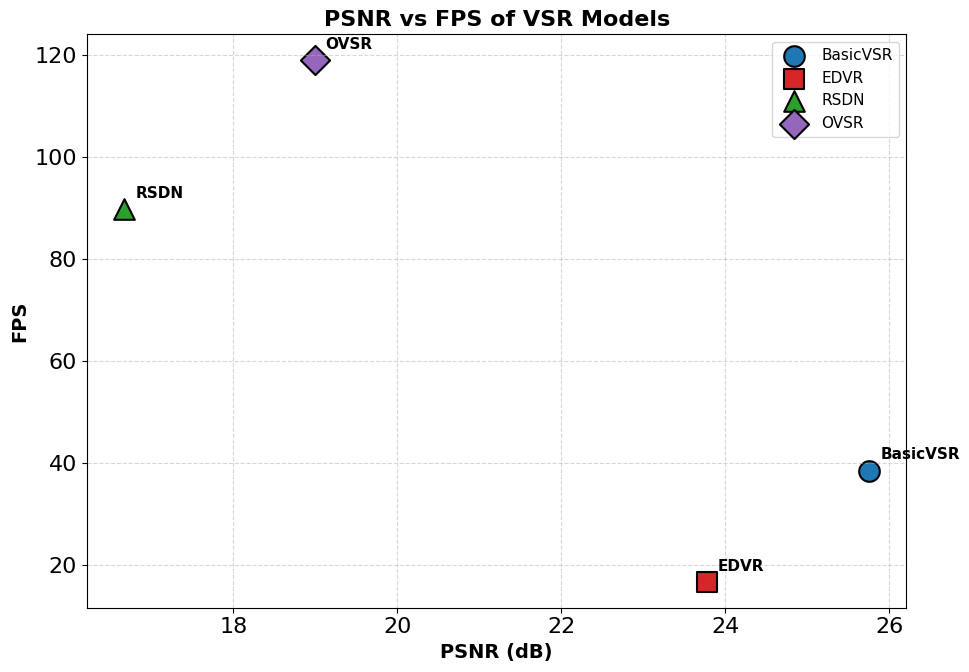

In [5]:
import matplotlib.pyplot as plt

# BI dataset results
models = ['BasicVSR', 'EDVR', 'RSDN', 'OVSR']
psnr = [25.7586, 23.7776, 16.6694, 18.9920]
fps = [38.60, 16.82, 89.89, 119.00]

# Different colors and marker styles
colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
markers = ['o', 's', '^', 'D']

plt.figure(figsize=(10, 7))
plt.rcParams.update({'font.size': 16})
# Plot each model separately
for i in range(len(models)):
    plt.scatter(
        psnr[i],
        fps[i],
        color=colors[i],
        marker=markers[i],
        s=220,
        edgecolors='black',
        linewidths=1.5,
        label=models[i]
    )

    # Add text labels
    plt.annotate(
        models[i],
        (psnr[i], fps[i]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=11,
        fontweight='bold'
    )

# Axis labels and title
plt.xlabel('PSNR (dB)', fontsize=14, fontweight='bold')
plt.ylabel('FPS', fontsize=14, fontweight='bold')
plt.title('PSNR vs FPS of VSR Models',
          fontsize=16,
          fontweight='bold')

# Style improvements
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()